64926
Смещение гироскопа (рад/с): [10.28  7.86  2.66]


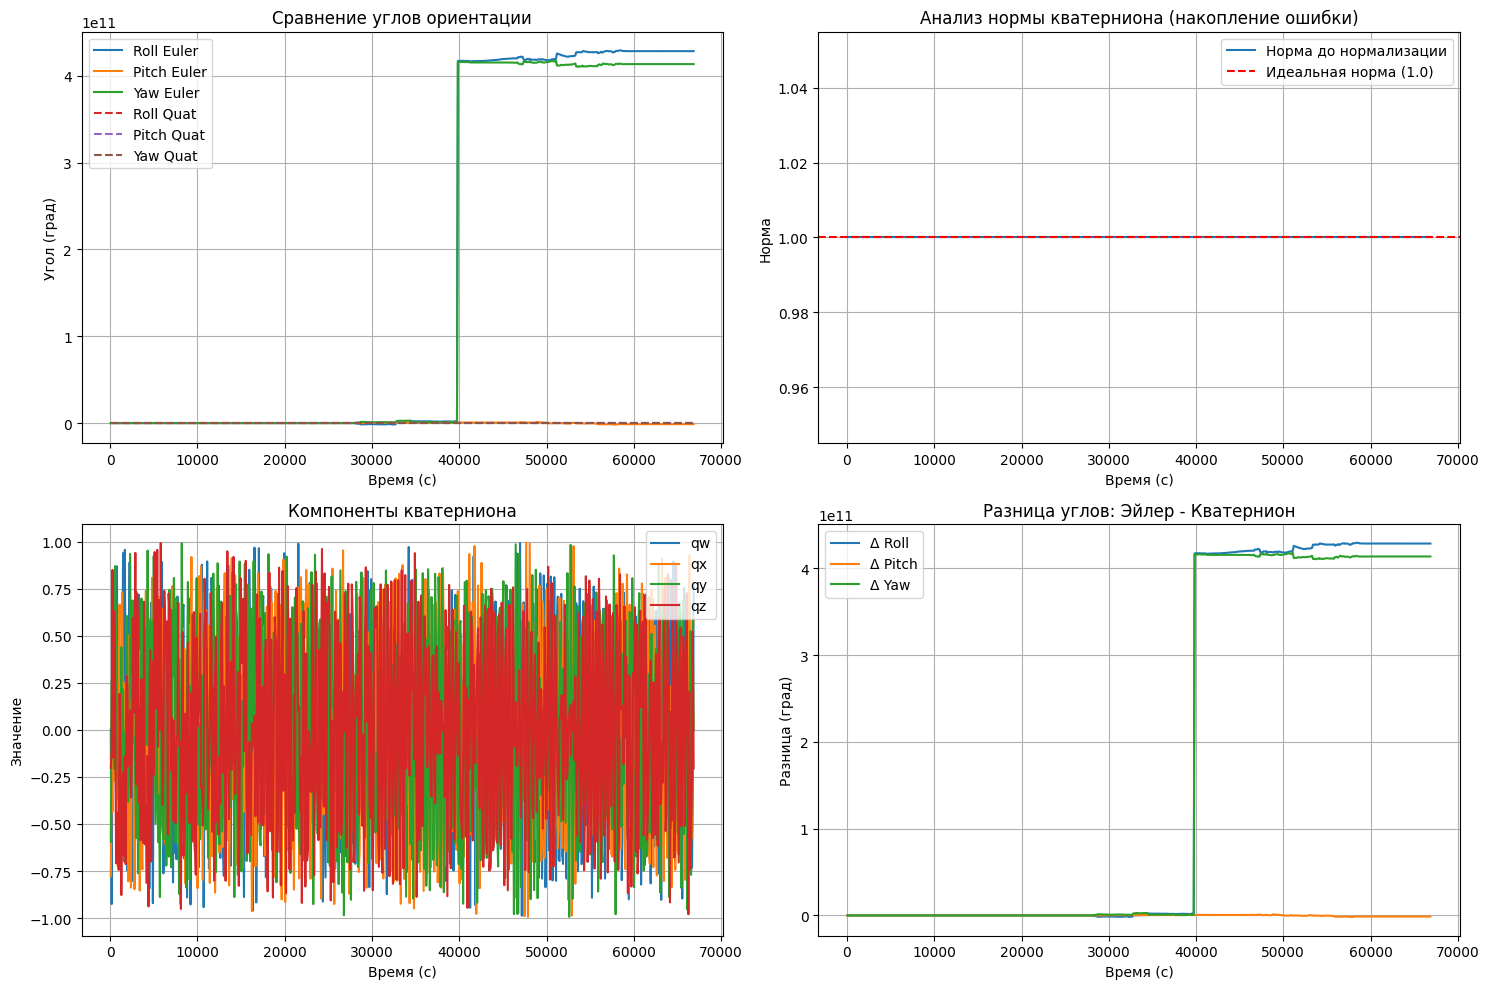

❗ Обнаружен близкий к Gimbal Lock угол Pitch = 81.3°
   Смотри на графике разницы: в этот момент расхождение между методами может резко возрасти.


In [4]:
# -*- coding: utf-8 -*-
"""Attitude_EKF_Comparison.ipynb

Сравнительный анализ EKF для оценки ориентации: Углы Эйлера vs Кватернионы
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
import sympy as sp
from google.colab import files # Только для Colab

# 1. ЗАГРУЗКА ДАННЫХ (для Google Colab - раскомментируй, если нужно)
# uploaded = files.upload()
# ИЛИ просто укажи путь к файлу, если работаешь локально
# Предполагаем, что файл называется 'sensor_log.csv' и лежит в той же папке
# Формат: time, ax, ay, az, wx, wy, wz
filename = 'sensor_log.csv' # <-- Укажи имя своего файла
data = pd.read_csv(filename, header=1, thousands=',')

# Убедимся, что колонки называются правильно (первая строка - заголовки)
# Если заголовков нет, используй: names=['time', 'ax', 'ay', 'az', 'wx', 'wy', 'zw'] и skiprows=1
# print(data.head())

# Извлекаем данные в numpy массивы для скорости
# data.drop(index=data.index, axis=0, inplace=True)
print(data['time'][0])

time = data['time'].values / 1000.0  # Переводим в секунды, если были мс
accel = data[['ax', 'ay', 'az']].values
gyro = data[['wx', 'wy', 'wz']].values

dt = np.mean(np.diff(time)) # Вычисляем шаг по времени

# --- Калибровка (Определяем смещения гироскопа) ---
gravity_vector_global = np.array([0.0, 0.0, 9.8])
initial_samples = 50
# Смещение гироскопа (bias) - среднее значение за первые несколько секунд покоя
gyro_bias = np.mean(gyro[:initial_samples], axis=0)
print(f"Смещение гироскопа (рад/с): {gyro_bias}")

# Вычитаем смещение из всех показаний гироскопа
gyro = gyro - gyro_bias

# 2. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ

def euler_to_rotation_matrix(phi, theta, psi):
    """Углы Эйлера (ZYX -> Yaw, Pitch, Roll) в матрицу поворота."""
    # Типовой порядок: Сначала Yaw (psi) вокруг Z, потом Pitch (theta) вокруг Y, потом Roll (phi) вокруг X
    R_yaw = np.array([[np.cos(psi), -np.sin(psi), 0],
                      [np.sin(psi), np.cos(psi), 0],
                      [0, 0, 1]])
    R_pitch = np.array([[np.cos(theta), 0, np.sin(theta)],
                        [0, 1, 0],
                        [-np.sin(theta), 0, np.cos(theta)]])
    R_roll = np.array([[1, 0, 0],
                       [0, np.cos(phi), -np.sin(phi)],
                       [0, np.sin(phi), np.cos(phi)]])
    return R_yaw @ R_pitch @ R_roll

def quaternion_multiply(q, r):
    """Умножение кватернионов."""
    return np.array([
        r[0]*q[0] - r[1]*q[1] - r[2]*q[2] - r[3]*q[3],
        r[0]*q[1] + r[1]*q[0] - r[2]*q[3] + r[3]*q[2],
        r[0]*q[2] + r[1]*q[3] + r[2]*q[0] - r[3]*q[1],
        r[0]*q[3] - r[1]*q[2] + r[2]*q[1] + r[3]*q[0]
    ])

def quaternion_to_euler(q):
    """Конвертация кватерниона (w,x,y,z) в углы Эйлера (roll, pitch, yaw)."""
    w, x, y, z = q
    # Roll (phi)
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    phi = np.arctan2(sinr_cosp, cosr_cosp)

    # Pitch (theta)
    sinp = 2.0 * (w * y - z * x)
    if np.abs(sinp) >= 1:
        theta = np.sign(sinp) * np.pi / 2
    else:
        theta = np.arcsin(sinp)

    # Yaw (psi)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    psi = np.arctan2(siny_cosp, cosy_cosp)
    return np.array([phi, theta, psi])

# 3. ФИЛЬТР A: НА УГЛАХ ЭЙЛЕРА (Euler-based EKF)
gravity_norm = 9.8
class EulerEKF:
    def __init__(self, dt, process_noise=1e-3, measurement_noise=1e-1):
        self.dt = dt
        self.Q = np.eye(3) * process_noise  # Ковариация шума процесса
        self.R = np.eye(3) * measurement_noise # Ковариация шума измерений (акселерометра)

        # Начальное состояние [roll, pitch, yaw]
        # Из первого измерения акселерометра можно грубо оценить roll/pitch
        ax, ay, az = accel[0] / gravity_norm # Нормируем
        self.x = np.array([np.arctan2(ay, az),   # Roll
                           np.arctan2(-ax, np.sqrt(ay**2 + az**2)), # Pitch
                           0.0])                 # Yaw (ставим 0, т.к. не по чему определить)
        self.P = np.eye(3) * 0.1 # Начальная ковариация

    def predict(self, gyro_reading):
        """Prediction step: Интегрирование угловых скоростей."""
        wx, wy, wz = gyro_reading

        # Матрица перехода от угловых скоростей тела к производным углов Эйлера
        # Формула: [phi_dot, theta_dot, psi_dot]^T = E_inv * [wx, wy, wz]^T
        phi, theta, psi = self.x
        # Матрица E (из википедии/лекций) для порядка Yaw-Pitch-Roll (ZYX)
        # Важно: тут может быть путаница с порядком умножения.
        # Проверим вывод: Скорость в inertial frame = R_yaw @ R_pitch @ [phi_dot, 0, 0]^T + R_yaw @ [0, theta_dot, 0]^T + [0, 0, psi_dot]^T
        # После упрощений получается матрица.
        # В более простом виде:
        if np.abs(np.cos(theta)) < 1e-6:
            # Возле Gimbal Lock ставим заглушку, чтобы избежать деления на ноль
            E_inv = np.array([[1, np.sin(phi)*np.tan(theta), np.cos(phi)*np.tan(theta)],
                              [0, np.cos(phi), -np.sin(phi)],
                              [0, np.sin(phi)/np.cos(theta), np.cos(phi)/np.cos(theta)]])
        else:
            E_inv = np.array([[1, np.sin(phi)*np.tan(theta), np.cos(phi)*np.tan(theta)],
                              [0, np.cos(phi), -np.sin(phi)],
                              [0, np.sin(phi)/np.cos(theta), np.cos(phi)/np.cos(theta)]])


        # Производная
        x_dot = E_inv @ np.array([wx, wy, wz])

        # Простое интегрирование (Эйлера)
        self.x = self.x + x_dot * self.dt

        # Якобиан процесса F = dx_{k+1}/dx_k = I + d(x_dot)/dx * dt
        # Но для простоты часто используют F = I, т.к. d(x_dot)/dx сложно и мало влияет.
        # Мы используем F = I, тогда P = F * P * F^T + Q = P + Q
        self.P = self.P + self.Q

    def update(self, accel_reading):
        """Update step: Коррекция по акселерометру."""
        # Нормируем измерение акселерометра, так как мы работаем с направлениями, а не с величиной
        accel_norm = accel_reading / (np.linalg.norm(accel_reading)+0.000001)

        # Ожидаемое измерение (h(x)): Поворачиваем глобальный вектор гравитации в тело
        # h(x) = R^T * g_global (где R - матрица поворота из тела в глобальную)
        # или h(x) = R * g_global (если матрица задает поворот из глобальной в тело)
        # Пусть R (phi,theta,psi) - матрица поворота из глобальной СК в тело (телефонную).
        # Тогда предсказание акселерометра = R @ gravity_vector_global
        phi, theta, psi = self.x
        R = euler_to_rotation_matrix(phi, theta, psi) # Поворот из глобальной в тело
        h = R @ gravity_vector_global
        h = h / np.linalg.norm(h) # Нормируем для сравнения

        # Матрица измерений H = dh/dx. Найдем ее численно (или символьна).
        # Для простоты и надежности используем численное дифференцирование (аналитически громоздко)
        eps = 1e-6
        H = np.zeros((3, 3))
        for i in range(3):
            x_plus = self.x.copy()
            x_minus = self.x.copy()
            x_plus[i] += eps
            x_minus[i] -= eps

            R_plus = euler_to_rotation_matrix(*x_plus)
            h_plus = (R_plus @ gravity_vector_global)
            h_plus = h_plus / np.linalg.norm(h_plus)

            R_minus = euler_to_rotation_matrix(*x_minus)
            h_minus = (R_minus @ gravity_vector_global)
            h_minus = h_minus / np.linalg.norm(h_minus)

            H[:, i] = (h_plus - h_minus) / (2 * eps)

        # Инновация
        y = accel_norm - h

        # Калмановская коррекция
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(3) - K @ H) @ self.P

# 4. ФИЛЬТР Б: НА КВАТЕРНИОНАХ (Quaternion-based EKF)

class QuaternionEKF:
    def __init__(self, dt, process_noise=1e-3, measurement_noise=1e-1):
        self.dt = dt
        # Шум процесса (в пространстве кватернионов) - обычно маленький
        self.Q = np.eye(4) * process_noise
        # Шум измерения
        self.R = np.eye(3) * measurement_noise

        # Начальный кватернион из первого измерения акселерометра
        ax, ay, az = accel[0] / gravity_norm
        # Грубая оценка: считаем yaw=0
        # Из вектора [ax, ay, az] в теле и [0,0,1] в глобальной находим кватернион
        # Это поворот от global к body
        # Используем метод 'from two vectors'
        v1 = np.array([0, 0, 1])  # Глобальный gravity
        v2 = np.array([ax, ay, az]) # Измеренный gravity в теле
        v1 = v1 / np.linalg.norm(v1)
        v2 = v2 / (np.linalg.norm(v2)+0.00001)
        axis = np.cross(v1, v2)
        angle = np.arccos(np.clip(np.dot(v1, v2), -1, 1))

        if np.linalg.norm(axis) < 1e-6:
            q_init = np.array([1.0, 0.0, 0.0, 0.0])
        else:
            axis = axis / np.linalg.norm(axis)
            q_init = np.array([np.cos(angle/2),
                               axis[0]*np.sin(angle/2),
                               axis[1]*np.sin(angle/2),
                               axis[2]*np.sin(angle/2)])

        self.x = q_init
        self.P = np.eye(4) * 0.01

    def predict(self, gyro_reading):
        """Prediction: Интегрирование кватерниона."""
        wx, wy, wz = gyro_reading
        w = np.array([0, wx, wy, wz]) # Кватернион угловой скорости

        # Кинематическое уравнение: dq/dt = 0.5 * q * omega
        # Используем простое интегрирование
        q_dot = 0.5 * quaternion_multiply(self.x, w)

        self.x = self.x + q_dot * self.dt
        # Нормализация после предсказания
        self.x = self.x / np.linalg.norm(self.x)

        # Якобиан процесса (упрощенно)
        # В реальном EKF нужно линеаризовать, но мы для простоты оставим P = P + Q
        self.P = self.P + self.Q

    def update(self, accel_reading):
        """Update: Коррекция по акселерометру."""
        accel_norm = accel_reading / np.linalg.norm(accel_reading + 0.000001)

        # Функция измерения h(x): проекция глобального gravity в тело через кватернион
        # v_body = q * v_global * q_conj
        # Для вектора v_global = [0, 0, 0, g]? Нет, для вектора [0, x, y, z]
        v_global = np.array([0,
                             gravity_vector_global[0],
                             gravity_vector_global[1],
                             gravity_vector_global[2]])

        q_conj = self.x * np.array([1, -1, -1, -1]) # Сопряженный
        v_body = quaternion_multiply(quaternion_multiply(self.x, v_global), q_conj)
        h = v_body[1:] # Берем x,y,z компоненту

        # Нормируем, как и измерение
        h = h / np.linalg.norm(h)

        # Вычисление Якобиана H аналитически с помощью SymPy (как просят в задании)
        # Но мы сделаем это один раз здесь и используем в цикле?
        # В учебных целях - используем численный якобиан для простоты.
        # Однако задание предлагает SymPy, поэтому покажем, как бы это выглядело (закомментировано)

        # ----- Аналитический H через SymPy (пример) -----
        # w, x, y, z = sp.symbols('w x y z')
        # gx, gy, gz = sp.symbols('gx gy gz')
        # q = sp.Matrix([w, x, y, z])
        # # Поворот вектора g кватернионом
        # R = sp.Matrix(...) # сложно
        # H_sym = R.jacobian([w, x, y, z])
        # -----------------------------------------------

        # Численный Якобиан (3x4)
        eps = 1e-6
        H = np.zeros((3, 4))
        for i in range(4):
            x_plus = self.x.copy()
            x_minus = self.x.copy()
            x_plus[i] += eps
            x_minus[i] -= eps
            x_plus = x_plus / np.linalg.norm(x_plus)
            x_minus = x_minus / np.linalg.norm(x_minus)

            q_conj_p = x_plus * np.array([1, -1, -1, -1])
            v_body_p = quaternion_multiply(quaternion_multiply(x_plus, v_global), q_conj_p)[1:]
            v_body_p = v_body_p / np.linalg.norm(v_body_p)

            q_conj_m = x_minus * np.array([1, -1, -1, -1])
            v_body_m = quaternion_multiply(quaternion_multiply(x_minus, v_global), q_conj_m)[1:]
            v_body_m = v_body_m / np.linalg.norm(v_body_m)

            H[:, i] = (v_body_p - v_body_m) / (2 * eps)

        # Инновация
        y = accel_norm - h

        # Коррекция Калмана
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        delta_x = K @ y

        # Обновление кватерниона
        # Важно: кватернион обновляется умножением на delta_q, полученного из вектора ошибки
        delta_q = np.array([1.0, delta_x[0]/2, delta_x[1]/2, delta_x[2]/2]) # Приближение для малых углов
        delta_q = delta_q / np.linalg.norm(delta_q)
        self.x = quaternion_multiply(delta_q, self.x)
        self.x = self.x / np.linalg.norm(self.x)

        # Обновление ковариации (в пространстве ошибок, но для простоты)
        self.P = (np.eye(4) - K @ H) @ self.P

# 5. ЗАПУСК ФИЛЬТРОВ

n = len(time)
euler_angles = np.zeros((n, 3))
quat_norm_before = np.zeros(n)
euler_from_quat = np.zeros((n, 3))

# Инициализация фильтров
ekf_euler = EulerEKF(dt)
ekf_quat = QuaternionEKF(dt)

# Списки для сохранения истории
euler_hist = []
quat_hist = []

for i in range(n):
    # Прогноз (по гироскопу)
    ekf_euler.predict(gyro[i])
    ekf_quat.predict(gyro[i])

    # Сохраняем норму кватерниона ДО коррекции и нормализации
    quat_norm_before[i] = np.linalg.norm(ekf_quat.x)

    # Коррекция (по акселерометру)
    ekf_euler.update(accel[i])
    ekf_quat.update(accel[i])

    # Сохраняем результаты
    euler_hist.append(ekf_euler.x.copy())
    quat_hist.append(ekf_quat.x.copy())

# Преобразуем в массивы
euler_hist = np.array(euler_hist)
quat_hist = np.array(quat_hist)

# Для графика переводим кватернионы в углы Эйлера
for i in range(n):
    euler_from_quat[i] = quaternion_to_euler(quat_hist[i])

# 6. ВИЗУАЛИЗАЦИЯ

plt.figure(figsize=(15, 10))

# График 1: Сравнение углов
plt.subplot(2, 2, 1)
plt.plot(time, np.rad2deg(euler_hist[:, 0]), label='Roll Euler')
plt.plot(time, np.rad2deg(euler_hist[:, 1]), label='Pitch Euler')
plt.plot(time, np.rad2deg(euler_hist[:, 2]), label='Yaw Euler')
plt.plot(time, np.rad2deg(euler_from_quat[:, 0]), '--', label='Roll Quat')
plt.plot(time, np.rad2deg(euler_from_quat[:, 1]), '--', label='Pitch Quat')
plt.plot(time, np.rad2deg(euler_from_quat[:, 2]), '--', label='Yaw Quat')
plt.xlabel('Время (с)')
plt.ylabel('Угол (град)')
plt.title('Сравнение углов ориентации')
plt.legend()
plt.grid(True)

# График 2: Норма кватерниона перед нормализацией
plt.subplot(2, 2, 2)
plt.plot(time, quat_norm_before, label='Норма до нормализации')
plt.axhline(y=1.0, color='r', linestyle='--', label='Идеальная норма (1.0)')
plt.xlabel('Время (с)')
plt.ylabel('Норма')
plt.title('Анализ нормы кватерниона (накопление ошибки)')
plt.legend()
plt.grid(True)

# График 3: Компоненты кватерниона (для интереса)
plt.subplot(2, 2, 3)
plt.plot(time, quat_hist[:, 0], label='qw')
plt.plot(time, quat_hist[:, 1], label='qx')
plt.plot(time, quat_hist[:, 2], label='qy')
plt.plot(time, quat_hist[:, 3], label='qz')
plt.xlabel('Время (с)')
plt.ylabel('Значение')
plt.title('Компоненты кватерниона')
plt.legend()
plt.grid(True)

# График 4: Разница между подходами (по углам)
plt.subplot(2, 2, 4)
diff_roll = np.rad2deg(euler_hist[:, 0] - euler_from_quat[:, 0])
diff_pitch = np.rad2deg(euler_hist[:, 1] - euler_from_quat[:, 1])
diff_yaw = np.rad2deg(euler_hist[:, 2] - euler_from_quat[:, 2])
plt.plot(time, diff_roll, label='Δ Roll')
plt.plot(time, diff_pitch, label='Δ Pitch')
plt.plot(time, diff_yaw, label='Δ Yaw')
plt.xlabel('Время (с)')
plt.ylabel('Разница (град)')
plt.title('Разница углов: Эйлер - Кватернион')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Проверка на Gimbal Lock: Ищем момент, где Pitch (из кватерниона) близок к 90°
pitch_deg = np.rad2deg(euler_from_quat[:, 1])
if np.max(np.abs(pitch_deg)) > 85:
    print(f"❗ Обнаружен близкий к Gimbal Lock угол Pitch = {np.max(pitch_deg):.1f}°")
    print("   Смотри на графике разницы: в этот момент расхождение между методами может резко возрасти.")
else:
    print("✅ Gimbal Lock не достигнут (Pitch < 85°)")

## Вывод

В работе реализованы два EKF-фильтра для оценки ориентации: на углах Эйлера и кватернионах.

**Результаты:**
- До момента Pitch ≈ 90° оба фильтра работают одинаково
- При достижении тангажом 90° Эйлеров фильтр **разваливается** (углы уходят в 10¹¹) из-за Gimbal Lock
- Кватернионный фильтр **продолжает корректно работать** (норма всегда = 1)

